# Un premier projet en Machine Learning

### Mettre en place l'environement
- pip install -r requirements.txt

### Charger les données

Nous allons travailler sur des données correspondant à des prix de maisons dans l'Iowa aux États-Unis. Chargez le dataset dans un dataframe `home_data` et vérifiez les données récupérées (taille, valeurs manquantes, nature des descripteurs, déséquilibre des classes, etc.)

In [36]:
import pandas as pd
# Chemin du fichier à lire
iowa_file_path = 'data/iowa_data.csv'

# Completer la ligne ci-dessous pour charger le fichier dans une variable home_data
home_data = pd.read_csv(iowa_file_path, index_col="Id")
home_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


### Explorer les donnees (EDA)



In [37]:
# Affiche les statistiques des données
# Affiche le nombre de lignes et de colonnes
print(home_data.shape)
# Affiche le type de chaque colonne
print(home_data.dtypes)
# Affiche les principales statistiques du jeu de données
home_data.describe()

(1470, 80)
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 80, dtype: object


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1470.000000,1211.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1462.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1460.000000
mean,56.863946,70.033856,10510.891837,6.097959,5.576190,1971.347619,1984.937415,103.244870,442.595238,47.240816,...,94.636735,46.646259,21.880952,3.386395,14.958503,2.740136,44.893878,6.320408,2007.819728,180921.195890
std,42.354486,24.221560,9951.394010,1.381068,1.113372,30.178811,20.627136,180.604575,455.478753,162.982299,...,126.541335,66.081576,60.980229,29.218719,55.581109,40.040966,498.577957,2.701144,1.330183,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7558.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9475.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,382.000000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11600.000000,7.000000,6.000000,2000.750000,2004.000000,164.750000,712.000000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


La méthode `.describe()` calcule puis affiche huit informations de base pour chacune des colonnes de l'ensemble de données. Le premier nombre (*count*) indique le nombre de valeurs manquantes.

Les valeurs manquantes surviennent pour de nombreuses raisons. Par exemple, la taille de la 2ème chambre ne peut pas être collectée si la maison ne comporte qu'une chambre. Les données manquantes sont une situation courante qu'il faut apprendre à gérer.

Le deuxième nombre (*mean*) correspond à la moyenne et le suivant (*std*) à l'écart type, qui mesure l'étalement numérique des valeurs.

Les valeurs *min, 25%, 50%, 75% et max* correspondent respectivement au minimum (*min*), au premier quartile (*25%*), au second quartile ou médiane (*50%*), au troisième quartile (*75%*) et enfin au maximum (*max*).

In [38]:
# Quelle est la taille moyenne des terrains (arrondie à l'entier le plus proche)?
avg_lot_size = 10511

# Quel est l'âge de la maison la plus récente (année actuelle - date de construction)
newest_home_age = 16

In [39]:
# Supprime les lignes avec des valeurs manquantes dans la colonne SalePrice
home_data.dropna(axis=0,subset=["SalePrice"],inplace=True)
# observez les conséquences
home_data.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


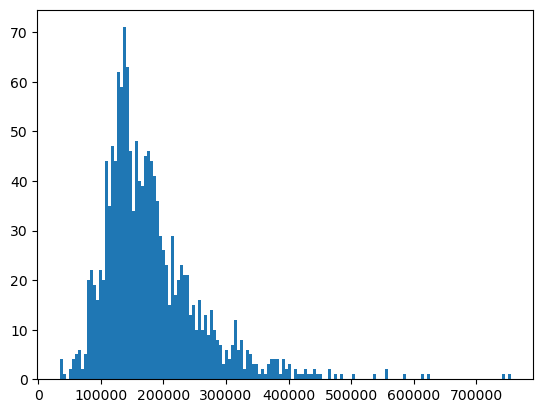

In [40]:
# Visualise l'histogramme de la colonne SalePrice
import matplotlib.pyplot as plt
plt.hist(home_data.SalePrice,bins=150)
plt.show()

### Sélectionner une cible de prédiction et créer l'ensemble de données d'entrainement X



In [41]:
# Affiche la liste des colonnes pour choisir la (une) variable cible
home_data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [42]:
# Complète la ligne ci-dessous pour stocker dans y
# la colonne de la variable cible (que tu décides prédire)
y = home_data.SalePrice

In [43]:
# Crée la liste des variables descriptives (features). Modifiez si vous voulez utiliser une autre liste.
feature_names = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']

# Sellectionne les données correspondant aux variables prédictives
X = home_data[feature_names]
X.shape

(1460, 7)

### Découper le jeu de données


Utilisez la fonction train_test_split pour diviser vos données.

Rappelez-vous, vos descriptions sont stockées dans le DataFrame X et votre cible est stockée dans y.

In [44]:
# Importer la fonction train_test_split 
from sklearn.model_selection import train_test_split

# Completer la ligne ci-dessous pour diviser les données en données d'entrainement et de validation
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.5, random_state=42)

### Spécifiez et entrainer (fitting) un modèle

Créez un `DecisionTreeRegressor` et enregistrez-le sous le nom `iowa_model`. Assurez-vous d'avoir effectué l'importation appropriée depuis sklearn pour exécuter cette commande.

Ensuite, ajustez le modèle que vous venez de définit en utilisant les données d'entraînement (seulement!).

In [45]:
from sklearn.tree import DecisionTreeRegressor

# spécification du modèle, with different parameters
iowa_model = DecisionTreeRegressor(random_state=42)

# Completer la ligne ci-dessous: Entraîne (fitting) le modèle avec les données d'entrainement 
iowa_model.fit(X_train,y_train)


DecisionTreeRegressor(random_state=42)

### Faites des prédictions sur les données de validation

In [46]:
# Completer la ligne ci-dessous: Predire les valeurs de la variable cible pour les données de validation
predictions = iowa_model.predict(X_val)

In [47]:
# Affiche les 5 premières prédictions
print(predictions[:5])

# Affiche les valeurs attendues pour ces 5 prédictions
print(y_val[:5])

[154000. 302000.  87000. 115000. 227680.]
Id
893     154500.0
1106    325000.0
414     115000.0
523     159000.0
1037    315500.0
Name: SalePrice, dtype: float64


### Calculer l'erreur absolue moyenne (mean_absolute_error) sur les données de test

In [54]:
# importer la fonction mean_absolute_error
from sklearn.metrics import mean_absolute_error

# Complète la ligne ci-dessous pour calculer l'erreur absolue moyenne (MAE)
# sur l'ensemble des données de validation
val_mae = mean_absolute_error(y_val,predictions)
print(val_mae)

# Ecris ta propre fonction pour calculer l'erreur absolue moyenne
def mae(y_true, y_pred):
    return abs(y_true - y_pred).mean()

val_mae_manuelle = mae(y_val,predictions)
print(val_mae_manuelle)

# Vérifie ta fonction mae
assert val_mae == val_mae_manuelle, f"Votre implementation de MAE donne un resultat different, la difference est {abs(val_mae-val_mae_manuelle)}"

30435.61506849315
30435.61506849315


### Refactorisation

In [ ]:
# Nous allons organiser nos traitements sous forme de fonctions
# pour pouvoir les réutiliser plus tard

# Fonction pour netttoyer les données
def clean_data(data):
    # Supprime les lignes avec des valeurs manquantes dans la colonne SalePrice
    data.dropna(axis=0,subset=["SalePrice"],inplace=True)
    return data

# Fonction pour diviser les données en données d'entrainement et de validation
def split_data(data, feature_names, target_name):
    # Sélectionne la variable cible que tu veux prédire
    y = ...
    # Sélectionne les données correspondant aux variables prédictives
    X = ...
    # Divise les données en données d'entrainement et de validation
    X_train, X_val, y_train, y_val = ...
    return X_train, X_val, y_train, y_val

# fonction pour entrainer le modèle et evaluer les performances
def score_dataset(X_train, X_val, y_train, y_val):
    ...


In [ ]:
# on relance tous les etapes
def run_experiment():
    # Charger les données
    iowa_file_path = 'data/iowa_data.csv'
    home_data = pd.read_csv(iowa_file_path)
    # Nettoyer les données
    home_data = clean_data(home_data)
    # Sélectionner les variables prédictives et la variable cible
    feature_names = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']
    target_name = 'SalePrice'
    # Diviser les données en données d'entrainement et de validation
    X_train, X_val, y_train, y_val = split_data(home_data, feature_names, target_name)
    # Evaluer la performance du modèle
    val_mae = score_dataset(X_train, X_val, y_train, y_val)
    print("Error du modèle: ", val_mae)

run_experiment()